In [1]:
!pip install tensorflow

## **1. Data loading and generators**

In [2]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

I0000 00:00:1781976180.464900  176638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781976180.465612  176638 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781976180.533892  176638 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781976181.758871  176638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [3]:
np.random.seed(42); tf.random.set_seed(42)

# Paths - change if needed
DATA_ROOT = Path("cats_dogs")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 128, 128
batch_size = 32
seed = 1337

In [4]:
# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        raise FileNotFoundError(f"No images found under {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

In [5]:
df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

In [6]:
# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

In [7]:
# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)

In [8]:
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [9]:
train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)

Found 20000 non-validated image filenames belonging to 2 classes.


In [10]:
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

Found 5000 non-validated image filenames belonging to 2 classes.


In [11]:
# Unlabeled test for inference only
test_flow = test_gen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

Found 12500 non-validated image filenames.


In [12]:
print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})

{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


## **2. Inspect the data**

Dans `train_flow`, les classes sont mappées via `train_flow.class_indices` (par exemple `cat` et `dog`) et `train_flow.labels` contient 20 000 étiquettes issues de `df_tr`. Comme la séparation a été faite en conservant la stratification par label, on dispose d’environ 10 000 images de chats et 10 000 images de chiens dans l’ensemble d’entraînement, ce qui signifie que les classes sont équilibrées. Les images peuvent varier visuellement en raison de la pose de l’animal, de l’échelle et du cadrage, des conditions d’éclairage (ombres, contre-jour, éclairage artificiel), et des arrière-plans très différents.

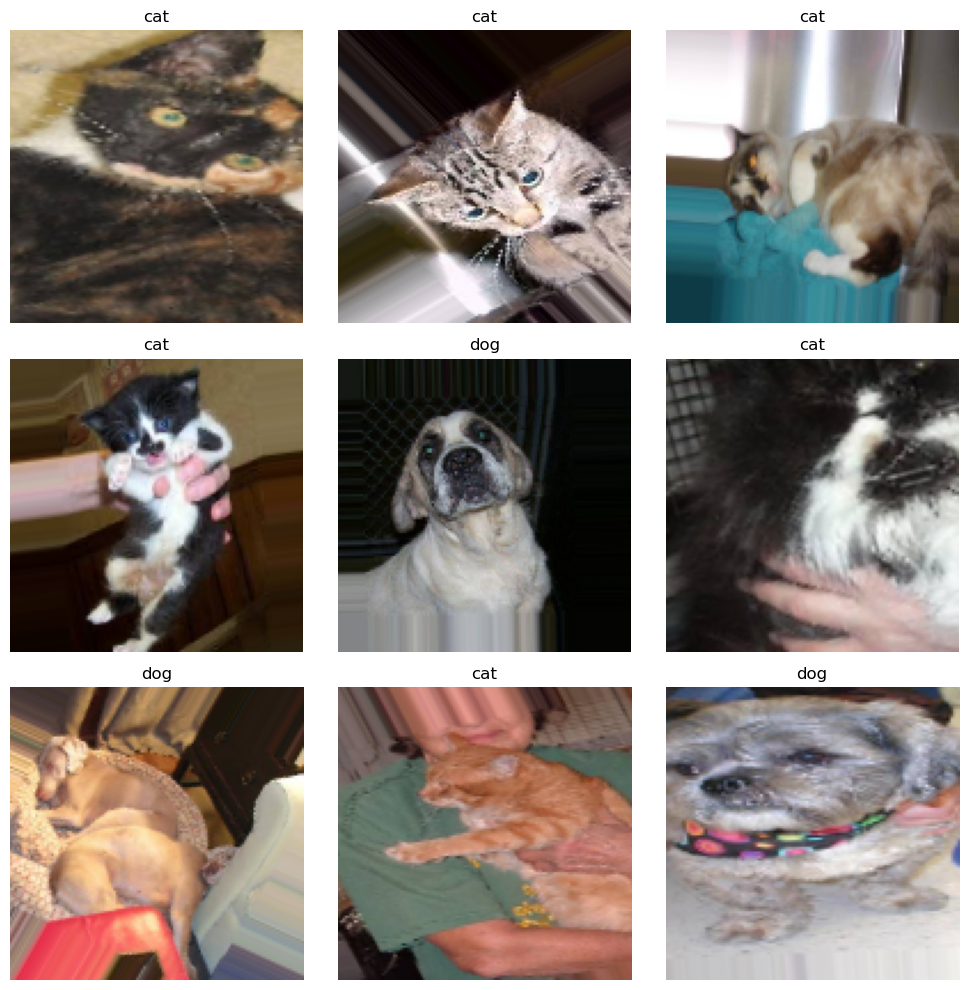

In [13]:
import matplotlib.pyplot as plt

batch_x, batch_y = next(train_flow)
class_names = {v: k for k, v in train_flow.class_indices.items()}

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, img, label in zip(axes.flat, batch_x[:9], batch_y[:9]):
    ax.imshow(img)
    ax.set_title(class_names[int(label)], fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

Indices visuels utiles pour distinguer les chats des chiens :
* Forme de la tête et du museau : museau plus fin chez le chat, plus large/rectangulaire chez le chien.
* Oreilles : souvent plus pointues ou rapprochées chez le chat, plus larges et écartées chez beaucoup de chiens.
* Proportions du corps : chats plus compacts et souples, chiens parfois plus massifs.
* Texture et motif du pelage : certains motifs et textures sont plus fréquents chez les chats.
* Contours du visage : ligne des yeux et du nez plus marquée chez le chat.

## **3. Define the model architecture**

Je vais construire un CNN avec plusieurs blocs convolutionnels.
Le premier bloc utilisera des filtres 3x3, par exemple 32 filtres, suivi d'une couche MaxPooling pour réduire les dimensions spatiales. Le deuxième bloc aura plus de filtres, par exemple 64 filtres 3x3, puis une autre couche MaxPooling pour comprimer encore les caractéristiques.
Le troisième bloc pourra utiliser 128 filtres 3x3, encore suivi de MaxPooling. J'ajouterai du Dropout avant les couches entièrement connectées pour régulariser le modèle et réduire le surapprentissage.
Enfin, les caractéristiques seront aplaties et envoyées dans des couches denses, puis dans une couche de sortie unique avec activation sigmoïde pour produire une probabilité pour la classification binaire chat/chien.

## **4. Choose the optimization setup**

* Optimiseur : Adam est un bon choix car il combine l'adaptation du taux d’apprentissage avec un momentum implicite, ce qui facilite une convergence rapide sur des tâches de classification d’images sans trop de réglages manuels.

* Taux d’apprentissage initial : un ordre de grandeur raisonnable est 0.001. C’est suffisamment élevé pour avancer vite au début, tout en restant assez bas pour éviter des oscillations importantes. Si le modèle diverge ou stagne, on pourra baisser ce taux.

* Taille du lot : batch_size = 32 est un bon point de départ pour des images 128x128 et un réseau CNN de taille moyenne. Cette taille permet de profiter d’une bonne estimation du gradient tout en restant compatible avec la plupart des GPU et CPU de bureau. Si la mémoire devient limitante, on peut réduire à 16.

* Stratégie de régularisation : utiliser **EarlyStopping** sur la perte de validation permet d’arrêter l’entraînement dès que le modèle ne s’améliore plus, ce qui évite le surapprentissage. 

## **5. Train the model**

In [14]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [15]:

def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title(f"{title} - loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="val accuracy")
    plt.title(f"{title} - accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

epochs = 10 #Test pour voir à quelle époque le modèle commence à surapprendre

In [16]:

model_fixed = build_model() #Entrainement du modèle

E0000 00:00:1781976184.928262  176638 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [17]:
history_fixed = model_fixed.fit(
    train_flow,
    epochs=epochs,
    validation_data=val_flow,
    verbose=1,
)

Epoch 1/10


I0000 00:00:1781976185.613231  176638 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


625/625 ━━━━━━━━━━━━━━━━━━━━ 294s 468ms/step - accuracy: 0.5470 - loss: 0.6877 - val_accuracy: 0.5726 - val_loss: 0.6764
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 355ms/step - accuracy: 0.5895 - loss: 0.6664 - val_accuracy: 0.6136 - val_loss: 0.6628
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 248s 396ms/step - accuracy: 0.6174 - loss: 0.6471 - val_accuracy: 0.6734 - val_loss: 0.6171
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 252s 402ms/step - accuracy: 0.6474 - loss: 0.6276 - val_accuracy: 0.6764 - val_loss: 0.6054
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 214s 341ms/step - accuracy: 0.6679 - loss: 0.6068 - val_accuracy: 0.6936 - val_loss: 0.5876
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 424ms/step - accuracy: 0.6808 - loss: 0.5940 - val_accuracy: 0.6916 - val_loss: 0.5822
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 275s 440ms/step - accuracy: 0.6884 - loss: 0.5868 - val_accuracy: 0.7052 - val_loss: 0.5688
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 415ms/step - accuracy: 0.6997 - loss: 0.57

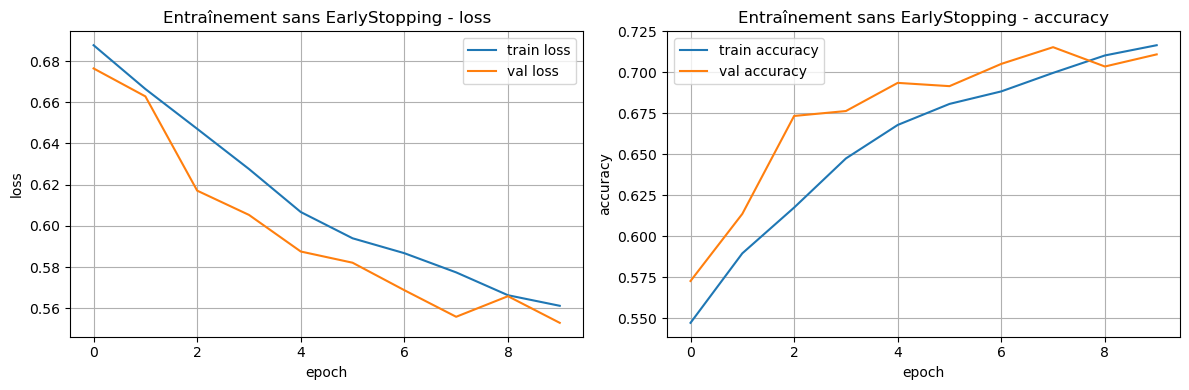

In [18]:


plot_history(history_fixed, "Entraînement sans EarlyStopping")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

In [19]:
model_early = build_model()
history_early = model_early.fit(
    train_flow,
    epochs=epochs,
    validation_data=val_flow,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 422ms/step - accuracy: 0.5365 - loss: 0.6867 - val_accuracy: 0.6006 - val_loss: 0.6578
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 223s 357ms/step - accuracy: 0.5968 - loss: 0.6617 - val_accuracy: 0.5912 - val_loss: 0.6532
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 355ms/step - accuracy: 0.6209 - loss: 0.6457 - val_accuracy: 0.6492 - val_loss: 0.6307
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 238s 380ms/step - accuracy: 0.6476 - loss: 0.6254 - val_accuracy: 0.6514 - val_loss: 0.6151
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 244s 390ms/step - accuracy: 0.6625 - loss: 0.6112 - val_accuracy: 0.6722 - val_loss: 0.6033
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 242s 387ms/step - accuracy: 0.6838 - loss: 0.5938 - val_accuracy: 0.6996 - val_loss: 0.5809
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 350ms/step - accuracy: 0.6887 - loss: 0.5855 - val_accuracy: 0.7106 - val_loss: 0.5683
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 220s 351ms/step - accuracy: 0.7008 -

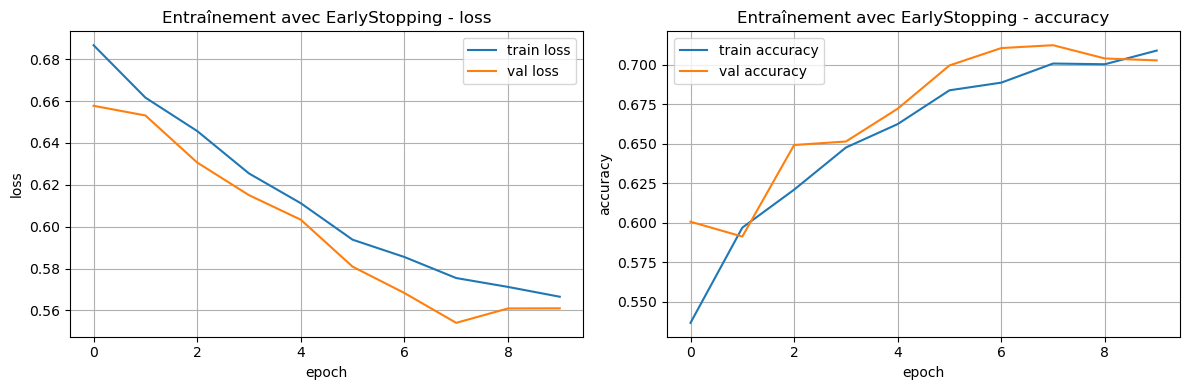

Fixed epochs: 10 epochs
EarlyStopping: 10 epochs


In [20]:

plot_history(history_early, "Entraînement avec EarlyStopping")

print(f"Fixed epochs: {len(history_fixed.history['loss'])} epochs")
print(f"EarlyStopping: {len(history_early.history['loss'])} epochs")


Surapprentissage se détecte quand la perte de validation remonte alors que la perte d'entraînement continue de baisser, ou quand l'exactitude d'entraînement augmente alors que l'exactitude de validation stagne ou recule. L'arrêt précoce empêche l'entraînement de continuer trop longtemps et limite le surapprentissage.


De plus, les courbes révèlent le compromis entre biais et variance. Une divergence entre les ensembles d’entraînement et de validation indique un surapprentissage. Pour y remédier, on peut utiliser une augmentation de données plus importante, un taux d’abandon plus élevé ou un nombre réduit de paramètres.

## **6. Evaluate on validation data**

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

val_loss, val_accuracy = model_early.evaluate(val_flow, verbose=0)

print(f"Validation loss: {round(val_loss, 4)}")
print(f"Validation accuracy: {round(val_accuracy, 4)}\n")


Validation loss: 0.554
Validation accuracy: 0.7124



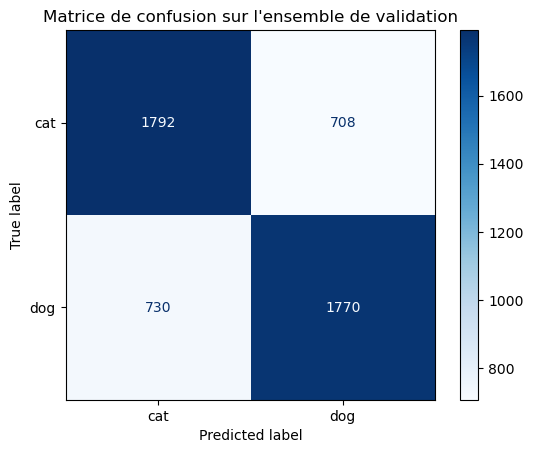

Classification report
              precision    recall  f1-score   support

         cat     0.7105    0.7168    0.7137      2500
         dog     0.7143    0.7080    0.7111      2500

    accuracy                         0.7124      5000
   macro avg     0.7124    0.7124    0.7124      5000
weighted avg     0.7124    0.7124    0.7124      5000

Faux positifs (chat prédit comme chien) : 708
Faux négatifs (chien prédit comme chat) : 730
Erreur prédominante : faux négatifs.
Le modèle a tendance à prédire 'cat' lorsque c'est en réalité 'dog'.
Cela suggère qu'un seuil plus bas que 0.5 pourrait réduire ces erreurs au prix d'un peu plus de faux positifs.


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

y_val_true = np.array(val_flow.labels if hasattr(val_flow, "labels") else val_flow.classes)
y_val_proba = model_early.predict(val_flow, verbose=0).ravel()
y_val_pred = (y_val_proba >= 0.5).astype(int)

cm = confusion_matrix(y_val_true, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[class_names[i] for i in sorted(class_names)])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion sur l'ensemble de validation")
plt.show()

print("Classification report")
print(classification_report(
    y_val_true,
    y_val_pred,
    target_names=[class_names[i] for i in sorted(class_names)],
    digits=4
))

tn, fp, fn, tp = cm.ravel()
print(f"Faux positifs (chat prédit comme chien) : {fp}")
print(f"Faux négatifs (chien prédit comme chat) : {fn}")

if fp > fn:
    print("Erreur prédominante : faux positifs.")
    print("Le modèle a tendance à prédire 'dog' lorsque c'est en réalité 'cat'.")
    print("Cela suggère qu'un seuil plus élevé que 0.5 pourrait réduire ces erreurs au prix d'un peu plus de faux négatifs.")
else:
    print("Erreur prédominante : faux négatifs.")
    print("Le modèle a tendance à prédire 'cat' lorsque c'est en réalité 'dog'.")
    print("Cela suggère qu'un seuil plus bas que 0.5 pourrait réduire ces erreurs au prix d'un peu plus de faux positifs.")

Si l'une des classes est mal reconnue, une augmentation ciblée de cette classe (par exemple plus de rotations, zooms, changements de luminosité) peut aider le réseau à mieux généraliser.

## **7. Run inference on the unlabeled test set**

In [28]:
from sklearn.metrics import f1_score

# Find threshold on validation set that maximizes F1
thresholds = np.linspace(0.0, 1.0, 101)
best_thr, best_f1 = 0.5, -1.0
for t in thresholds:
    preds = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val_true, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = t

print(f"Selected threshold={best_thr:.2f} (val F1={best_f1:.4f})")

# Predict probabilities on test set (order matches df_test_full because shuffle=False)
probs_test = model_early.predict(test_flow, verbose=1).ravel()

# Build output DataFrame and save CSV
df_out = df_test_full.copy()
df_out["prob_dog"] = probs_test
df_out["étiquette_préd"] = np.where(df_out["prob_dog"] >= best_thr, "dog", "cat")
df_out = df_out.rename(columns={"filepath": "chemin d'accès"})

out_path = DATA_ROOT / "test_predictions.csv"
df_out.to_csv(out_path, index=False, encoding="utf-8")
print(f"Saved {len(df_out)} rows to {out_path}")
df_out.head()

Selected threshold=0.36 (val F1=0.7355)
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step
Saved 12500 rows to cats_dogs/test_predictions.csv


,chemin d'accès,prob_dog,étiquette_préd
0,cats_dogs/test/test/4881.jpg,0.358114,cat
1,cats_dogs/test/test/5365.jpg,0.662915,dog
2,cats_dogs/test/test/508.jpg,0.225400,cat
3,cats_dogs/test/test/2173.jpg,0.409475,dog
4,cats_dogs/test/test/8630.jpg,0.399886,dog


## **8. Compare baseline vs augmentation**

Found 20000 non-validated image filenames belonging to 2 classes.
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 280ms/step - accuracy: 0.5750 - loss: 0.6669 - val_accuracy: 0.6148 - val_loss: 0.6411
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 183s 290ms/step - accuracy: 0.6327 - loss: 0.6337 - val_accuracy: 0.6740 - val_loss: 0.6054
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 334ms/step - accuracy: 0.6806 - loss: 0.5972 - val_accuracy: 0.6472 - val_loss: 0.6244


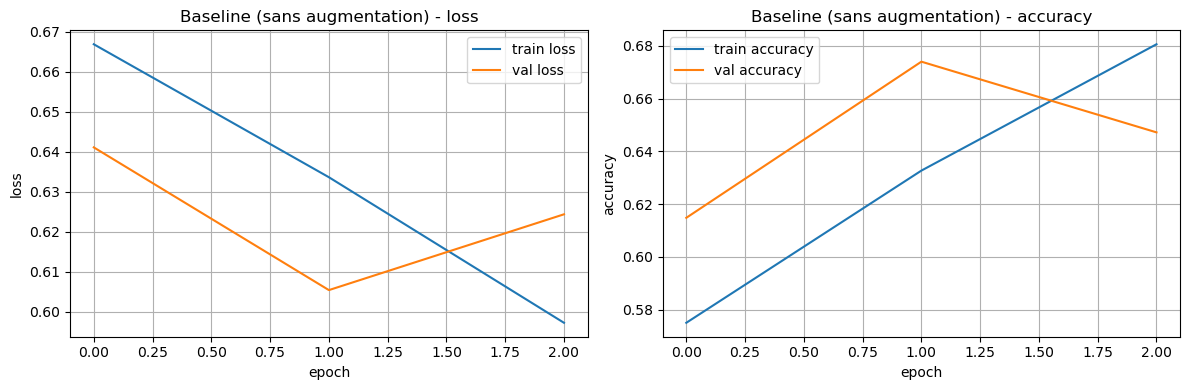

In [30]:

# Train baseline model without data augmentation
baseline_gen = ImageDataGenerator(rescale=1./255)

baseline_train_flow = baseline_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)

baseline_model = build_model()
baseline_history = baseline_model.fit(
    baseline_train_flow,
    epochs=epochs,
    validation_data=val_flow,
    callbacks=[early_stopping],
    verbose=1,
)

plot_history(baseline_history, "Baseline (sans augmentation)")


In [33]:

# Compare metrics
baseline_loss, baseline_accuracy = baseline_model.evaluate(val_flow, verbose=0)
print(f"\n=== COMPARAISON ===")
print(f"Baseline   - Loss: {round(baseline_loss, 4)}, Accuracy: {round(baseline_accuracy, 4)}")
print(f"Augmented  - Loss: {round(val_loss, 4)}, Accuracy: {round(val_accuracy, 4)}")
print(f"\nÉcart de généralisation (différence de précision de validation): {round(abs(val_accuracy - baseline_accuracy), 4)}")
print(f"Loss improvement with augmentation: {round(baseline_loss - val_loss, 4)}")




=== COMPARAISON ===
Baseline   - Loss: 0.6411, Accuracy: 0.6148
Augmented  - Loss: 0.554, Accuracy: 0.7124

Écart de généralisation (différence de précision de validation): 0.0976
Loss improvement with augmentation: 0.0871


L'augmentation des données améliore la précision de la validation et le modèle généralise mieux aux données non vues avec l'entraînement augmenté. L'augmentation permet un entraînement plus long avant le surapprentissage (l'arrêt précoce est déclenché plus tard).

## **9. Class imbalance handling**

In [34]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix


In [35]:

# Calculer les poids de classe à partir de df_tr et réentraîner avec class_weight

# y_train en indices (0/1)
y_train = df_tr["label"].map(train_flow.class_indices).astype(int).values


In [36]:

# Comptes et poids
counts = pd.Series(y_train).value_counts().sort_index()
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}


In [37]:

print("Counts (par classe index):")
print(counts.to_dict())
print("Class weights:", class_weight)


Counts (par classe index):
{0: 10000, 1: 10000}
Class weights: {0: 1.0, 1: 1.0}


In [38]:

# Identifier la classe minoritaire (index et nom)
minority_idx = int(counts.idxmin())
minority_name = class_names[minority_idx]
print(f"Minority class: {minority_idx} -> {minority_name}")


Minority class: 0 -> cat


In [39]:

# Construire et entraîner le modèle avec class_weight
model_cw = build_model()
history_cw = model_cw.fit(
    train_flow,
    epochs=epochs,
    validation_data=val_flow,
    callbacks=[early_stopping],
    class_weight=class_weight,
    verbose=1,
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 321ms/step - accuracy: 0.5655 - loss: 0.6778 - val_accuracy: 0.6040 - val_loss: 0.6543
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 313ms/step - accuracy: 0.6004 - loss: 0.6584 - val_accuracy: 0.6104 - val_loss: 0.6468
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 197s 315ms/step - accuracy: 0.6206 - loss: 0.6453 - val_accuracy: 0.6574 - val_loss: 0.6213


In [40]:

# Évaluer sur la validation
val_loss_cw, val_acc_cw = model_cw.evaluate(val_flow, verbose=0)
print(f"\nValidation - loss: {val_loss_cw:.4f}, accuracy: {val_acc_cw:.4f}")



Validation - loss: 0.6543, accuracy: 0.6040


In [41]:

# Prédictions et métriques (utilise best_thr si défini, sinon 0.5)
thr = float(best_thr) if "best_thr" in globals() else 0.5
y_val_proba_cw = model_cw.predict(val_flow, verbose=0).ravel()
y_val_pred_cw = (y_val_proba_cw >= thr).astype(int)
y_val_true = np.array(val_flow.labels if hasattr(val_flow, "labels") else val_flow.classes)


In [42]:

cm_cw = confusion_matrix(y_val_true, y_val_pred_cw)
print("\nConfusion matrix (val):")
print(cm_cw)



Confusion matrix (val):
[[  87 2413]
 [  36 2464]]


In [43]:

report = classification_report(
    y_val_true,
    y_val_pred_cw,
    target_names=[class_names[i] for i in sorted(class_names)],
    digits=4
)
print("\nClassification report (val):")
print(report)



Classification report (val):
              precision    recall  f1-score   support

         cat     0.7073    0.0348    0.0663      2500
         dog     0.5052    0.9856    0.6680      2500

    accuracy                         0.5102      5000
   macro avg     0.6063    0.5102    0.3672      5000
weighted avg     0.6063    0.5102    0.3672      5000



In [44]:

prec, rec, f1, _ = precision_recall_fscore_support(y_val_true, y_val_pred_cw, labels=[minority_idx], zero_division=0)
print(f"Minority class '{minority_name}' - precision: {prec[0]:.4f}, recall: {rec[0]:.4f}, f1: {f1[0]:.4f}")


Minority class 'cat' - precision: 0.7073, recall: 0.0348, f1: 0.0663


Remarque: l'utilisation de class_weight favorise généralement le rappel de la classe minoritaire (plus d'exemples de la minorité sont correctement détectés), au prix possible d'une baisse de précision globale ou d'une augmentation des faux positifs pour cette classe.

## **10. Save artifacts for reuse**

In [47]:
import json

save_root = DATA_ROOT / "artifacts"
save_root.mkdir(parents=True, exist_ok=True)

saved_model_dir = save_root / "best_model_savedmodel"
h5_model_path = save_root / "best_model.h5"
config_path = save_root / "training_config.json"

# Sauvegarder le modèle entraîné au format TensorFlow SavedModel et H5
model_early.export(saved_model_dir)
model_early.save(h5_model_path)

# Sauvegarder les métadonnées d'entraînement dans un fichier JSON
training_config = {
    "dataset_root": str(DATA_ROOT),
    "image_size": [IMG_HEIGHT, IMG_WIDTH],
    "batch_size": batch_size,
    "seed": seed,
    "optimizer": "Adam",
    "learning_rate": float(model_early.optimizer.learning_rate),
    "loss": "binary_crossentropy",
    "metrics": ["accuracy"],
    "early_stopping": {
        "monitor": "val_loss",
        "patience": 3,
        "restore_best_weights": True,
    },
    "class_indices": train_flow.class_indices,
    "best_threshold": float(best_thr) if "best_thr" in globals() else 0.5,
    "history": {k: [float(x) for x in v] for k, v in history_early.history.items()},
    "model_config_json": model_early.to_json(),
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(training_config, f, indent=2, ensure_ascii=False)

print(f"Saved TensorFlow SavedModel to: {saved_model_dir}")
print(f"Saved H5 model to: {h5_model_path}")
print(f"Saved training configuration to: {config_path}")

INFO:tensorflow:Assets written to: cats_dogs/artifacts/best_model_savedmodel/assets


INFO:tensorflow:Assets written to: cats_dogs/artifacts/best_model_savedmodel/assets


Saved artifact at 'cats_dogs/artifacts/best_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140671760712144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140671760717712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140671760725584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140671760717904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140671760718096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140671760722512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140671760722320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140671760716368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140673508731664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140673508731472: TensorSpec(shape=(), dtype=tf.resource,

Saved TensorFlow SavedModel to: cats_dogs/artifacts/best_model_savedmodel
Saved H5 model to: cats_dogs/artifacts/best_model.h5
Saved training configuration to: cats_dogs/artifacts/training_config.json


Les poids et les métadonnées sont sauvegardés pour permettre la reconstruction exacte du modèle et assurer la reproductibilité.

## **11. Extensions**

In [ ]:
# Apprentissage par transfert avec MobileNetV2 figé
# Bénéfice attendu : réutilisation de caractéristiques visuelles pré-entraînées,
# meilleure généralisation et entraînement plus rapide sur un backbone léger.

def build_model_tl():
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights="imagenet",
        pooling="avg",
    )
    base.trainable = False  # dorsale figée

    model = tf.keras.Sequential([
        base,
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

model_tl = build_model_tl()
model_tl.summary()